In [1]:
import os
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns

In [2]:
from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt


def calculate_gait_mae(ground_truth: np.ndarray, prediction: np.ndarray, tolerance: int = 20):
    """
    Matches gait events and computes overall and per-class MAE in one pass.

    Args:
        ground_truth: Array of ground truth labels.
        prediction: Array of predicted labels.
        tolerance: Max distance to consider a match.

    Returns:
        A tuple containing:
        - overall_mae (float): The MAE across all matched events.
        - per_class_mae (dict): A dictionary mapping class labels to their MAE.
    """
    gt_indices = np.where(ground_truth > 0)[0]
    available_preds = list(np.where(prediction > 0)[0])
    
    # Store tuples of (label, absolute_error) for each successful match
    errors_by_class = []
    
    # Greedily match each ground truth event to the closest prediction
    for gt_idx in gt_indices:
        gt_label = ground_truth[gt_idx]
        best_dist = float('inf')
        best_match_idx = -1
        
        # Find the closest available prediction of the same class within tolerance
        for pred_idx in available_preds:
            if prediction[pred_idx] == gt_label:
                dist = abs(gt_idx - pred_idx)
                if dist <= tolerance and dist < best_dist:
                    best_dist = dist
                    best_match_idx = pred_idx
        
        # If a match is found, record its error and remove it from the pool
        if best_match_idx != -1:
            error = abs(gt_idx - best_match_idx)
            errors_by_class.append((gt_label, error))
            available_preds.remove(best_match_idx)
            
    if not errors_by_class:
        return np.nan, {}

    # --- Calculate Final Metrics ---
    
    # Overall MAE is the mean of all collected errors
    all_errors = [err for lbl, err in errors_by_class]
    overall_mae = np.mean(all_errors)
    
    # Per-class MAE is calculated by grouping errors by label
    unique_labels = sorted(np.unique([lbl for lbl, err in errors_by_class]))
    per_class_mae = {
        int(label): np.mean([err for lbl, err in errors_by_class if lbl == label])
        for label in unique_labels
    }
    
    return overall_mae, per_class_mae


# @hydra.main(config_path="../configs", config_name="train_config", version_base="1.3")
def eval(data_set: str, model_fpath: str, fold: int, return_preds_targets=None):
    with initialize(config_path="../configs", job_name="train", version_base="1.3"):
        config = compose(config_name="train_config")
    pl.seed_everything(config.general.random_state)
    all_files = glob(config.general.data_path, recursive=True)
    all_files = np.sort(all_files)
    print(f"Processing: {len(all_files)} samples")

    ids = [int(i.split("/")[-1].split("_")[0]) for i in all_files]
    group_df = pd.read_csv(config.general.group_file, index_col="ID")
    group_df.columns = ["group"]
    group_df = group_df[group_df.group.notna()]
    group_df.replace("h", 0, inplace=True)
    group_df.replace("p", 1, inplace=True)
    grouping = group_df.loc[ids].group.values

    skf = StratifiedKFold(
        n_splits=config.general.n_splits,
        shuffle=True,
        random_state=config.general.random_state,
    )

    # Outer loop for K-Fold cross-validation
    # This loop creates the primary TEST set for each fold.
    for cur_fold, (train_val_index, test_index) in enumerate(
        skf.split(np.arange(len(ids)).reshape(-1, 1), grouping)
    ):
        
        if cur_fold != fold:
            continue
        print("cur_fold", cur_fold)
        print("input fold", fold)
        print(
            f"=============== FOLD {cur_fold + 1}/{config.general.n_splits} ================"
        )
        print("current_test set:", test_index)
        # Split data into a temporary training+validation set and the final test set
        X_train_val, X_test = (
            np.arange(len(ids))[train_val_index],
            np.arange(len(ids))[test_index],
        )
        print(f"X_train_val:", X_train_val)
        print(f"train_val_index:", train_val_index)
        print(f"X_test:", X_test)
        print(f"test_index:", test_index)
        
        y_train_val, y_test = grouping[train_val_index], grouping[test_index]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val,
            y_train_val,
            test_size=0.25,
            stratify=y_train_val,
            random_state=1,
        )

        model = LitSeq2Seq(
            input_dim=config.model.input_dim,
            output_dim=config.model.output_dim,
            hidden_dim=config.model.hidden_dim,
            num_layers=config.model.num_layers,
            dropout_prob=config.model.dropout_prob,
            learning_rate=config.model.learning_rate,
            teacher_forcing_ratio=config.model.teacher_forcing_ratio,
        )

        current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        run_name = f"GRU-expandlabel{config.data.expand_labels}_{current_time}"
        
        checkpoint_callback = ModelCheckpoint(
            monitor=config.training.monitor_metric,
            mode=config.training.monitor_mode,
            save_top_k=config.training.save_top_k,
            dirpath=f"{config.general.project_name}/{run_name}/checkpoints/",
            filename="model-{epoch:02d}-{val_f1score:.2f}",
        )
            
        checkpoint_callback.best_model_path = model_fpath
        print(f"Best model: {checkpoint_callback.best_model_path}")
        device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        best_model = LitSeq2Seq.load_from_checkpoint(checkpoint_callback.best_model_path).to(device_)

        testset_f1_scores = []
        testset_pc_f1_scores = []
        testset_pc_precision = []
        testset_pc_recall = []
        testset_mae = []
        testset_pc_mae = []
        testset_cm = []
        all_preds = []
        all_targets = []
        
        if data_set == "test":
            cur_set_to_test = X_test
        else:
            cur_set_to_test = X_val

        print("X_test:", X_test)
        print("X_val:", X_val)
        
        group_assigment = []
        counter = 0
        for curr_test_idx in cur_set_to_test.tolist():
            print(f" =============== Currently Evaluating curr_test_idx: {curr_test_idx} =============== ")
            if counter == 0:
                test_datamodule = GaitDataModule(all_files,
                                                 batch_size=1024,
                                                 window_size=config.data.window_size,
                                                 step_size=config.data.window_size,
                                                 train_idx=X_train.squeeze(), 
                                                 val_idx=X_val.squeeze()[:1], # We load validation/test set via the test_idx here
                                                 test_idx=[curr_test_idx],
                                                 expand_labels=0,
                                                 acc_sheet_name="Linear Accelerometer",
                                                 num_workers=16,
                                                 zscale=True,
                                                )
                test_datamodule.setup(data_set)
                trainset_stats = test_datamodule.train_dataset.zscale_stats
            
            counter+=1
            test_datamodule = GaitDataModule(all_files,
                                             batch_size=1024,
                                             window_size=config.data.window_size,
                                             step_size=config.data.window_size,
                                             train_idx=X_train.squeeze(), 
                                             val_idx=X_val.squeeze()[:1], # We load validation/test set via the test_idx here
                                             test_idx=[curr_test_idx],
                                             expand_labels=0,
                                             acc_sheet_name="Linear Accelerometer",
                                             num_workers=16,
                                             zscale=True,
                                             zscale_stats=trainset_stats,
                                            )
            
            test_datamodule.setup(data_set)
            test_dataloader = test_datamodule.test_dataloader()
            # if data_set == "test":
            #     test_dataloader = test_datamodule.test_dataloader()
            # elif data_set == "val": 
            #     test_dataloader = test_datamodule.val_dataloader()
            # else:
            #     raise ValueError(f"Not supported -> {data_set}")
            best_model.eval()
            with torch.no_grad():
                pred=[]
                target=[]
                for sample_input, sample_target in test_dataloader:
                    sample_input = sample_input.to(device_)
                    sample_target = sample_target.to(device_)
                    print(sample_input.shape)
                    predicted_output = best_model(sample_input, sample_target, teacher_forcing_ratio=0.0)
                    pred.append(predicted_output)
                    target.append(sample_target)
                
                cur_pred = torch.concat(pred).reshape(-1, 3)
                cur_pred = torch.nn.functional.softmax(cur_pred, dim=-1).argmax(1)
                cur_target = torch.concat(target).reshape(-1)
                reshaped_input = sample_input.reshape(-1, sample_input.shape[-1]).cpu().numpy()
                
                print("Pred", cur_pred.shape, "Target", cur_target.shape)
                # cm = MulticlassConfusionMatrix(num_classes=3, normalize="true").to(device_)
                # cm.update(cur_pred, cur_target)
                # fig_, ax_ = cm.plot()
                # plt.show()
                
                ALIGN_TOLERANCE = 3
                merged_preds = evaluate.merge_clustered_events(cur_pred.cpu().numpy())
                merged_targets = evaluate.merge_clustered_events(cur_target.cpu().numpy())
                aligned_preds = evaluate.align_events(merged_targets, merged_preds, ALIGN_TOLERANCE)
                
                
                cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
                cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                fig_, ax_ = cm.plot()
                plt.show()
                unnormalized_cm = MulticlassConfusionMatrix(num_classes=3, normalize=None)
                unnormalized_cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                ucm_tensor = unnormalized_cm.compute()
                testset_cm.append(ucm_tensor)
                print(ucm_tensor)
                
                num_classes = 3
                f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro')
                f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                print(f"Macro F1-Score: {f1_macro_score.item():.4f} ✨")

                pc_f1score = MulticlassF1Score(num_classes=num_classes, average='none')
                perclass_f1scores = pc_f1score(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                testset_pc_f1_scores.append(perclass_f1scores)
                print(f"perclass_f1scores:", perclass_f1scores)

                pc_precision = MulticlassPrecision(num_classes=num_classes, average='none')
                perclass_precision = pc_precision(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                testset_pc_precision.append(perclass_precision)
                print(f"perclass_precision:", perclass_precision)

                pc_recall = MulticlassRecall(num_classes=num_classes, average='none')
                perclass_recall = pc_recall(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                testset_pc_recall.append(perclass_recall)
                print(f"perclass_recall:", perclass_recall)

                f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                
                overall, per_class = calculate_gait_mae(merged_targets, merged_preds)
                overall = overall.item() if not np.isnan(overall) else np.nan
                print(f"MAE overall: {overall:.4f} ✨")
                print(f"MAE per_class: {per_class} ✨")
                testset_f1_scores.append(f1_macro_score)
                testset_mae.append(overall)
                testset_pc_mae.append(per_class)
                group_assigment.append(grouping[curr_test_idx])

                if return_preds_targets:
                    all_preds.append(aligned_preds)
                    all_targets.append(merged_targets)
                
            # break
        # break
    return {
            "testset_f1_scores": torch.tensor(testset_f1_scores).numpy(),
            "testset_pc_f1_scores": torch.stack(testset_pc_f1_scores).numpy(),
            "testset_pc_precision": torch.stack(testset_pc_precision).numpy(),
            "testset_pc_recall": torch.stack(testset_pc_recall).numpy(),
            "testset_mae": np.stack(testset_mae),
            "testset_pc_mae": testset_pc_mae,
            "testset_cm": torch.stack(testset_cm).numpy(),
            "group": np.stack(group_assigment),
            "all_preds": all_preds,
            "all_targets": all_targets,
           }


# 1. Evaluate Validation set

In [4]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [0, 1, 2, 4, 8]
# exp_labels = [2]
# data_set = "val"
data_set = "val" # using train here because we are loading all dataset anyway and using training set stats to normalize data
for i in range(num_folds):
    for j in exp_labels:
        print(i, j)
        # curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        # curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/RerunExp-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        save_name = f"ZscaledRerunExp4-Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
        if data_set == "test" or data_set == "val":
            save_name = f"{data_set}set_{save_name}"
        if not os.path.exists(save_name):
            print(f"=== Running model: {save_name} ===")
            testset_results = eval(data_set=data_set, model_fpath=curr_model_path, fold=i)
            np.savez(save_name, **testset_results)

0 0
0 1
0 2
0 4
0 8
1 0
1 1
1 2
1 4
1 8
2 0
2 1
2 2
2 4
2 8
3 0
3 1
3 2
3 4
3 8
4 0
4 1
4 2
4 4
4 8


# 2. Plot 

## 2.1 Plot F1-score and MAE box plot validation set

 === Processing valset_Fold1_explabel0_model-epoch=162-val_f1score=0.52.npz === 
 === Processing valset_Fold1_explabel1_model-epoch=60-val_f1score=0.78.npz === 
 === Processing valset_Fold1_explabel2_model-epoch=88-val_f1score=0.86.npz === 
 === Processing valset_Fold1_explabel4_model-epoch=58-val_f1score=0.91.npz === 
 === Processing valset_Fold1_explabel8_model-epoch=60-val_f1score=0.94.npz === 
 === Processing valset_Fold2_explabel0_model-epoch=118-val_f1score=0.39.npz === 
 === Processing valset_Fold2_explabel1_model-epoch=62-val_f1score=0.81.npz === 
 === Processing valset_Fold2_explabel2_model-epoch=53-val_f1score=0.87.npz === 
 === Processing valset_Fold2_explabel4_model-epoch=50-val_f1score=0.91.npz === 
 === Processing valset_Fold2_explabel8_model-epoch=95-val_f1score=0.95.npz === 
 === Processing valset_Fold3_explabel0_model-epoch=96-val_f1score=0.37.npz === 
 === Processing valset_Fold3_explabel1_model-epoch=60-val_f1score=0.74.npz === 
 === Processing valset_Fold3_explabel2

/tmp/ipykernel_2792660/2899146187.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([u"\u00B1 10 [ms]", u"\u00B1 20 [ms]", u"\u00B1 40 [ms]", u"\u00B1 80 [ms]"])


<bound method Axes.set_title of <Axes: title={'center': 'Event Detection Performance on Validation Set (5-fold CV)'}, xlabel="Model's Label Expansion Setting", ylabel='F1-Score'>>

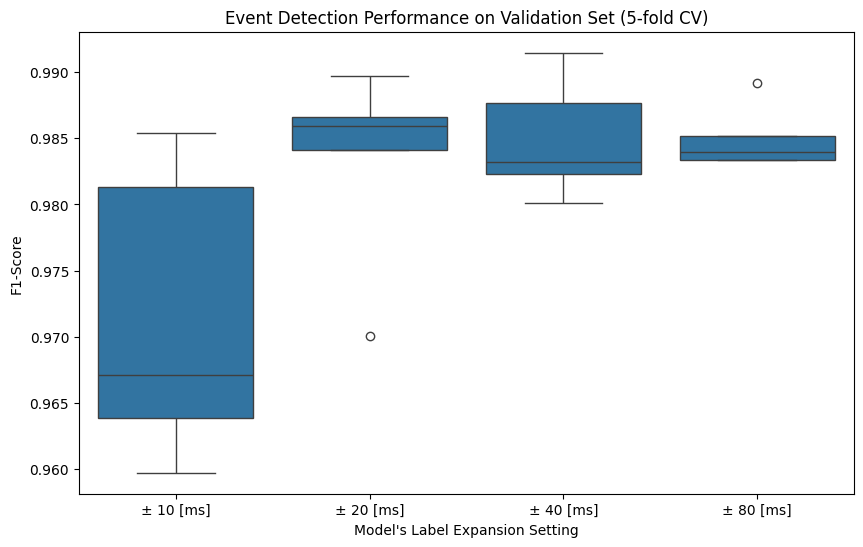

In [5]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [0, 1, 2, 4, 8]
all_results = []
for i in range(num_folds):
    for j in exp_labels:
        # curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/RerunExp-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        fname = f"valset_Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
        print(f" === Processing {fname} === ")
        curr_results = np.load(fname, allow_pickle=True)
        curr_results = {**curr_results}
        curr_results["fold"] = i + 1
        curr_results["explabel"] = j
        all_results.append(curr_results)

all_results_df = pd.DataFrame(all_results)
print(all_results_df.head())

# Simplified Code for MEAN OF LIST LENGTHS
cur_feature_name = "testset_f1_scores"
cur_metric_name = "F1-Score"
f1_scores = all_results_df.groupby(["fold", "explabel"])[[cur_feature_name]].agg(lambda s: s.apply(np.nanmean))
f1_scores = f1_scores.reset_index()
f1_scores.head()

# f1_scores.groupby(["explabel"]).mean()
# f1_scores.groupby(["explabel"]).std()
plot_df = pd.melt(f1_scores[f1_scores.explabel!=0], id_vars=["fold", "explabel"])


plot_df = plot_df.rename(columns={"explabel": "Expand", "value": cur_metric_name})
plt.figure(figsize=(10, 6))
g = sns.boxplot(data=plot_df, x="Expand", y=cur_metric_name)
plt.title("Event Detection Performance on Validation Set (5-fold CV)")
g.set_xticklabels([u"\u00B1 10 [ms]", u"\u00B1 20 [ms]", u"\u00B1 40 [ms]", u"\u00B1 80 [ms]"])
g.set_xlabel("Model's Label Expansion Setting")
g.set_title

In [6]:
# all_results_df[all_results_df.explabel==1].testset_f1_scores.apply(lambda x: x.mean()).mean()

In [7]:
import pandas as pd
import numpy as np
from scipy import stats

# --- Simplified Aggregation ---

# A single lambda function to calculate the 95% Confidence Interval bounds (CI)
# t.interval returns a tuple: (lower_bound, upper_bound)
def get_ci_bounds(series, confidence=0.95):
    """Calculates the 95% CI (lower, upper) for a Series."""
    if series.empty:
        return np.nan, np.nan
    # stats.sem calculates the Standard Error of the Mean (sigma / sqrt(n))
    sem = stats.sem(series, ddof=1)
    # stats.t.interval computes the confidence interval
    return stats.t.interval(confidence, len(series) - 1, loc=series.mean(), scale=sem)

# Assuming your DataFrame 'f1_scores' and column 'cur_feature_name' are defined.
decimals = 3

# 1. Aggregate the data (combining the CI calculation)
report_df = f1_scores.groupby('explabel')[cur_feature_name].agg(
    mean_val='mean',
    std_val='std',
    ci_bounds=get_ci_bounds, # Uses the single function to get a tuple of bounds
    count='size'
).reset_index()

# 2. Split the CI tuple into separate columns for easier formatting
report_df[['ci_lower', 'ci_upper']] = pd.DataFrame(
    report_df['ci_bounds'].tolist(),
    index=report_df.index
)
report_df = report_df.drop(columns=['ci_bounds'])


# --- Simplified Formatting (Using f-strings and round) ---

# 3. Create the formatted columns using vectorization (not row-wise apply) where possible
# Note: Using .round() before f-string formatting ensures correct precision.

# Mean +/- Std Column
report_df['Mean_Std'] = (
    report_df['mean_val'].round(decimals).astype(str) +
    ' $\\pm$ ' +
    report_df['std_val'].round(decimals).astype(str)
)

# Confidence Interval Column
report_df['95% CI'] = (
    '[' +
    report_df['ci_lower'].round(decimals).astype(str) +
    ', ' +
    report_df['ci_upper'].round(decimals).astype(str) +
    ']'
)


# 4. Select and rename final columns for publication
publication_table = report_df[['explabel', 'count', 'Mean_Std', '95% CI']]
publication_table.columns = ['Experiment Label (Group)', 'N', 'Mean $\\pm$ Std. Dev.', '95% Confidence Interval']



In [8]:
publication_table.columns = ["Label Expand", "CV-folds", 'Mean $\pm$ Std. Dev.', '95% Confidence Interval']
publication_table = publication_table.iloc[:, 1:3]
publication_table

,CV-folds,Mean $\pm$ Std. Dev.
0,5,0.481 $\pm$ 0.176
1,5,0.971 $\pm$ 0.011
2,5,0.983 $\pm$ 0.008
3,5,0.985 $\pm$ 0.005
4,5,0.985 $\pm$ 0.002


In [36]:
# Reporting validation set metrics
publication_table.to_latex()

'\\begin{tabular}{lrl}\n\\toprule\n & CV-folds & Mean $\\pm$ Std. Dev. \\\\\n\\midrule\n0 & 5 & 0.481 $\\pm$ 0.176 \\\\\n1 & 5 & 0.971 $\\pm$ 0.011 \\\\\n2 & 5 & 0.983 $\\pm$ 0.008 \\\\\n3 & 5 & 0.985 $\\pm$ 0.005 \\\\\n4 & 5 & 0.985 $\\pm$ 0.002 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [31]:
# Just get the median value
f1_scores.groupby('explabel')[cur_feature_name].agg(
    mean_val='median',
    std_val='std',
    ci_bounds=get_ci_bounds, # Uses the single function to get a tuple of bounds
    count='size'
).reset_index()

,explabel,mean_val,std_val,ci_bounds,count
0,0,0.452167,0.176385,"(0.2619913329807989, 0.7000138054164179)",5
1,1,0.967129,0.011229,"(0.9575538791266537, 0.9854400001915836)",5
2,2,0.985902,0.007652,"(0.9737507579474785, 0.9927521469444893)",5
3,4,0.983190,0.004571,"(0.9792589890200812, 0.990610028580932)",5
4,8,0.983945,0.002466,"(0.9819293440540432, 0.9880533992092014)",5


## 2.2 Test set - Plot confusion matrix with CI on the test set using best model only

Seed set to 42


=== Running model: testset_Fold1_explabel2_model-epoch=86-val_f1score=0.88.npz ===
Processing: 46 samples
cur_fold 0
input fold 0
=============== FOLD 1/5 ================
current_test set: [ 4 11 12 13 14 20 23 24 28 34]
X_train_val: [ 0  1  2  3  5  6  7  8  9 10 15 16 17 18 19 21 22 25 26 27 29 30 31 32
 33 35 36 37 38 39 40 41 42 43 44 45]
train_val_index: [ 0  1  2  3  5  6  7  8  9 10 15 16 17 18 19 21 22 25 26 27 29 30 31 32
 33 35 36 37 38 39 40 41 42 43 44 45]
X_test: [ 4 11 12 13 14 20 23 24 28 34]
test_index: [ 4 11 12 13 14 20 23 24 28 34]
Best model: /home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-11_20-10-10/checkpoints/model-epoch=86-val_f1score=0.88.ckpt
X_test: [ 4 11 12 13 14 20 23 24 28 34]
X_val: [37 43 19 17 22 44  9 10 26]
 =============== Currently Evaluating curr_test_idx: 4 =============== 
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_41_T1/41_1_2mW_IPhone.xls


/tmp/ipykernel_2849940/2210105483.py:107: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_df.replace("p", 1, inplace=True)


cropped_array shape: (49, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_08_T1/08_1_2mW_IPhone.xls
cropped_array shape: (48, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_01_T1/01_1_2mW_IPhone.xls
cropped_array shape: (53, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_42_T1/42_1_2mW_IPhone.xls
cropped_array shape: (51, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_04_T1/04_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_10_T1/10_1_2mW_IPhone.xls
cropped_array shape: (51, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_28_T1/28_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/T

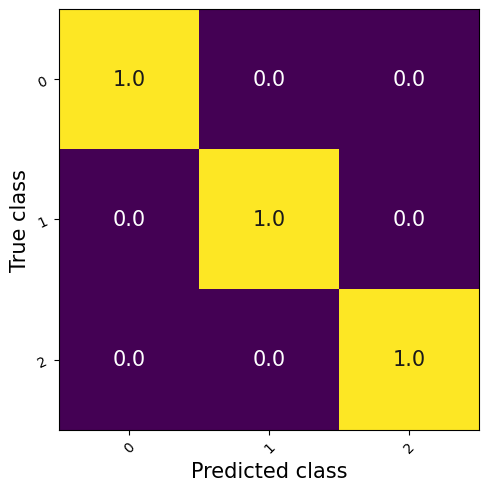

tensor([[12275,     1,     2],
        [    0,   133,     0],
        [    0,     0,   133]])
Macro F1-Score: 0.9962 ✨
perclass_f1scores: tensor([0.9999, 0.9963, 0.9925])
perclass_precision: tensor([1.0000, 0.9925, 0.9852])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 0.5602 ✨
MAE per_class: {1: np.float64(0.5789473684210527), 2: np.float64(0.5413533834586466)} ✨
 =============== Currently Evaluating curr_test_idx: 11 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_13_T1/13_1_2mW_IPh

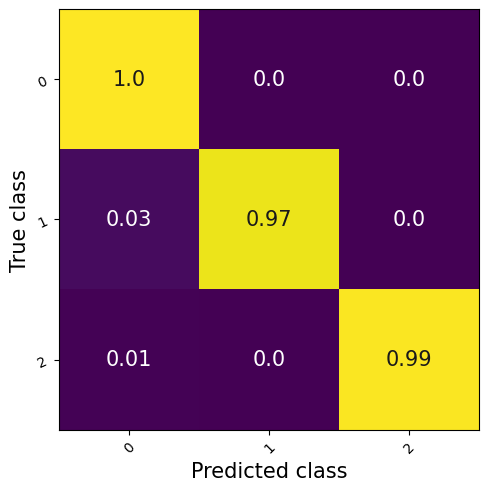

tensor([[12525,     5,     4],
        [    4,   129,     0],
        [    1,     0,   132]])
Macro F1-Score: 0.9824 ✨
perclass_f1scores: tensor([0.9994, 0.9663, 0.9814])
perclass_precision: tensor([0.9996, 0.9627, 0.9706])
perclass_recall: tensor([0.9993, 0.9699, 0.9925])
MAE overall: 0.8830 ✨
MAE per_class: {1: np.float64(1.0681818181818181), 2: np.float64(0.6992481203007519)} ✨
 =============== Currently Evaluating curr_test_idx: 12 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_14_T1/14_1_2mW_IPh

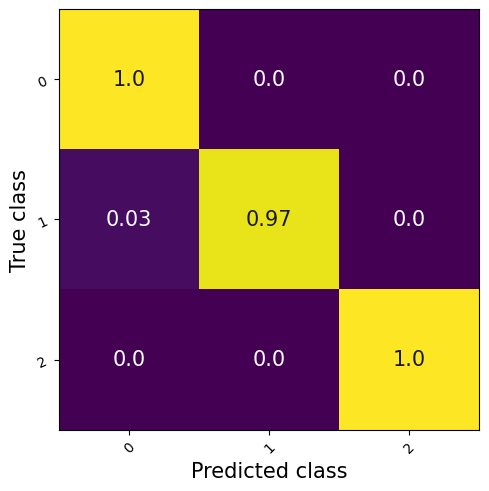

tensor([[12499,     6,     1],
        [    5,   142,     0],
        [    0,     0,   147]])
Macro F1-Score: 0.9863 ✨
perclass_f1scores: tensor([0.9995, 0.9627, 0.9966])
perclass_precision: tensor([0.9996, 0.9595, 0.9932])
perclass_recall: tensor([0.9994, 0.9660, 1.0000])
MAE overall: 1.0850 ✨
MAE per_class: {1: np.float64(1.7619047619047619), 2: np.float64(0.40816326530612246)} ✨
 =============== Currently Evaluating curr_test_idx: 13 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_15_T1/15_1_2mW_IP

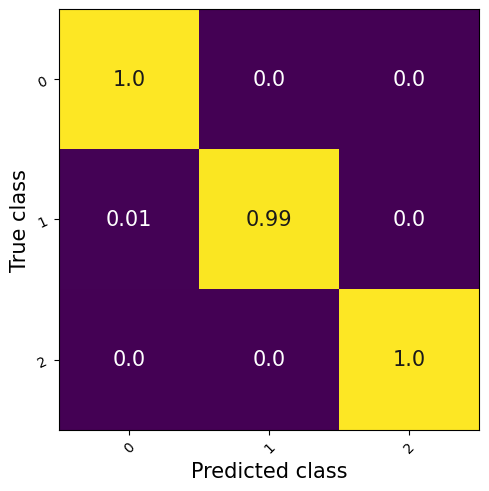

tensor([[12497,     1,     2],
        [    1,   149,     0],
        [    0,     0,   150]])
Macro F1-Score: 0.9955 ✨
perclass_f1scores: tensor([0.9998, 0.9933, 0.9934])
perclass_precision: tensor([0.9999, 0.9933, 0.9868])
perclass_recall: tensor([0.9998, 0.9933, 1.0000])
MAE overall: 0.6600 ✨
MAE per_class: {1: np.float64(0.5666666666666667), 2: np.float64(0.7533333333333333)} ✨
 =============== Currently Evaluating curr_test_idx: 14 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_16_T1/16_1_2mW_IPh

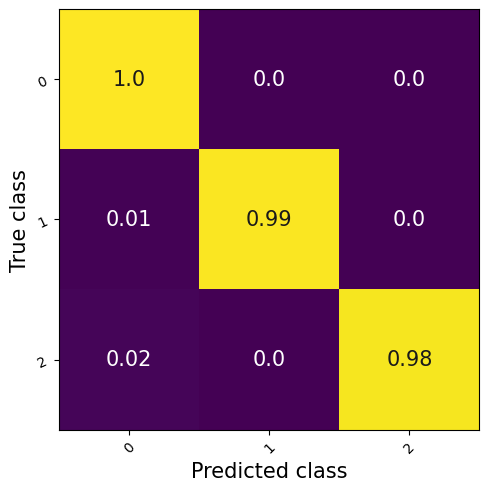

tensor([[12283,     0,     1],
        [    1,   129,     0],
        [    2,     0,   128]])
Macro F1-Score: 0.9948 ✨
perclass_f1scores: tensor([0.9998, 0.9961, 0.9884])
perclass_precision: tensor([0.9998, 1.0000, 0.9922])
perclass_recall: tensor([0.9999, 0.9923, 0.9846])
MAE overall: 1.2519 ✨
MAE per_class: {1: np.float64(0.6589147286821705), 2: np.float64(1.8449612403100775)} ✨
 =============== Currently Evaluating curr_test_idx: 20 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_23_T1/23_1_2mW_IPh

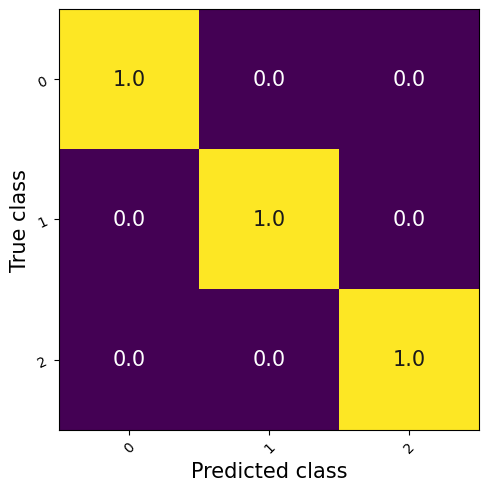

tensor([[12541,     2,     1],
        [    0,   128,     0],
        [    0,     0,   128]])
Macro F1-Score: 0.9961 ✨
perclass_f1scores: tensor([0.9999, 0.9922, 0.9961])
perclass_precision: tensor([1.0000, 0.9846, 0.9922])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 1.4062 ✨
MAE per_class: {1: np.float64(1.03125), 2: np.float64(1.78125)} ✨
 =============== Currently Evaluating curr_test_idx: 23 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_26_T1/26_1_2mW_IPhone.xls
cropped_array 

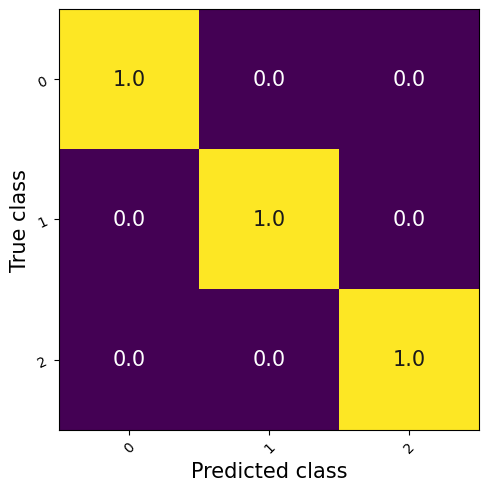

tensor([[12527,     2,     1],
        [    0,   135,     0],
        [    0,     0,   135]])
Macro F1-Score: 0.9963 ✨
perclass_f1scores: tensor([0.9999, 0.9926, 0.9963])
perclass_precision: tensor([1.0000, 0.9854, 0.9926])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 0.7963 ✨
MAE per_class: {1: np.float64(0.4222222222222222), 2: np.float64(1.1703703703703703)} ✨
 =============== Currently Evaluating curr_test_idx: 24 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_27_T1/27_1_2mW_IPh

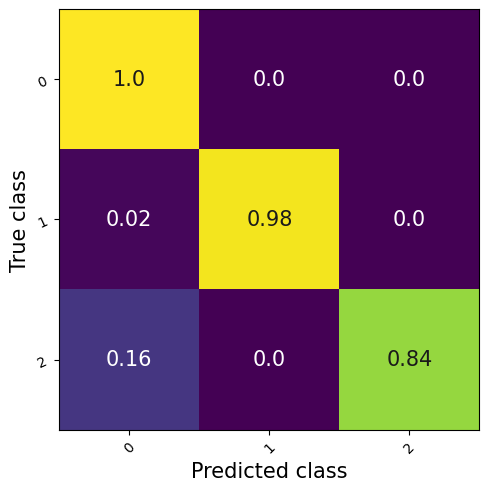

tensor([[12577,     3,     5],
        [    2,   106,     0],
        [   17,     0,    90]])
Macro F1-Score: 0.9557 ✨
perclass_f1scores: tensor([0.9989, 0.9770, 0.8911])
perclass_precision: tensor([0.9985, 0.9725, 0.9474])
perclass_recall: tensor([0.9994, 0.9815, 0.8411])
MAE overall: 0.9849 ✨
MAE per_class: {1: np.float64(1.1495327102803738), 2: np.float64(0.7934782608695652)} ✨
 =============== Currently Evaluating curr_test_idx: 28 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_31_T1/31_1_2mW_IPh

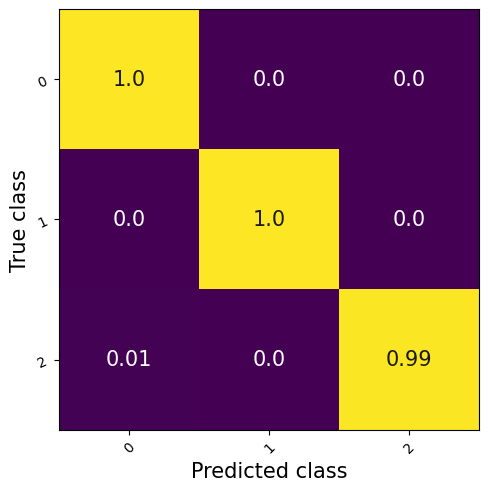

tensor([[12265,     3,     1],
        [    0,   138,     0],
        [    1,     0,   136]])
Macro F1-Score: 0.9939 ✨
perclass_f1scores: tensor([0.9998, 0.9892, 0.9927])
perclass_precision: tensor([0.9999, 0.9787, 0.9927])
perclass_recall: tensor([0.9997, 1.0000, 0.9927])
MAE overall: 1.1934 ✨
MAE per_class: {1: np.float64(1.2318840579710144), 2: np.float64(1.1544117647058822)} ✨
 =============== Currently Evaluating curr_test_idx: 34 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_37_T1/37_1_2mW_IPh

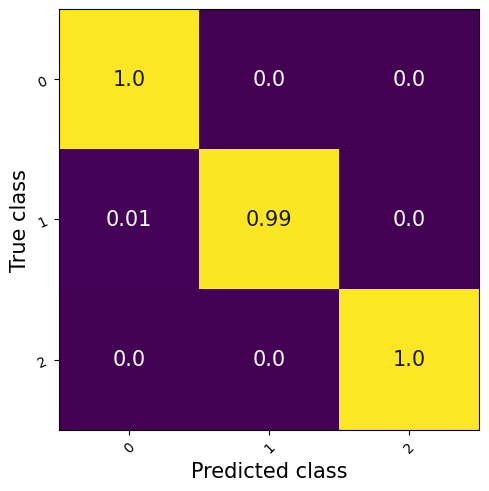

tensor([[12542,     3,     0],
        [    1,   127,     0],
        [    0,     0,   127]])
Macro F1-Score: 0.9948 ✨
perclass_f1scores: tensor([0.9998, 0.9845, 1.0000])
perclass_precision: tensor([0.9999, 0.9769, 1.0000])
perclass_recall: tensor([0.9998, 0.9922, 1.0000])
MAE overall: 1.0196 ✨
MAE per_class: {1: np.float64(1.34375), 2: np.float64(0.6929133858267716)} ✨


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

In [18]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [2]
data_set = "test"

for i in range(num_folds):
    for j in exp_labels:
        # curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        save_name = f"Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
        if data_set == "test":
            save_name = f"{data_set}set_{save_name}"
        # if not os.path.exists(save_name):
        print(f"=== Running model: {save_name} ===")
        testset_results = eval(data_set=data_set, model_fpath=curr_model_path, fold=i)
        np.savez(save_name, **testset_results)

In [ ]:
testset_all_results = []
testset_fnames = np.sort(glob("testset_Fold*"))
for fname in testset_fnames:
    print(f"Loading {fname}")
    curr_results = np.load(fname, allow_pickle=True)
    curr_results = {**curr_results}
    curr_results["fold"] = i + 1
    curr_results["explabel"] = j
    testset_all_results.append(curr_results)

In [ ]:
testset_all_results_df = pd.DataFrame(testset_all_results)
testset_all_results_df


In [ ]:
testset_all_results_df.testset_mae.apply(lambda x:len(x))

In [ ]:
cm_per_fold = testset_all_results_df.testset_cm.apply(lambda x: np.stack(x).sum(0)/np.stack(x).sum(0).sum(1))
cm_per_fold

In [ ]:
combined_cm = testset_all_results_df.testset_cm.apply(lambda x: np.stack(x).sum(0)).sum(0)
normalized_cm = (combined_cm/combined_cm.sum(1)).round(2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# ... other imports ...

def plot_confusion_matrix(cm, class_names, title, fmt, cbar_label, cmap=plt.cm.Blues, file_name='confusion_matrix.png'):
    # ... (function body as executed above) ...
    fig, ax = plt.subplots(figsize=(5, 5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        linewidths=0.5,
        linecolor='black',
        cbar=False,
        # cbar_kws={'label': cbar_label, 'orientation': 'vertical', 'pad': 0.04, 'aspect': 30},
        annot_kws={"fontsize": 16, "fontweight": "bold"},
        ax=ax,
        square=True
    )
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=5)
    ax.set_ylabel('True Label', fontsize=20, fontweight='medium')
    ax.set_xlabel('Predicted Label', fontsize=20, fontweight='medium')

    # Set class labels on ticks, centering them
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks + 0.5)
    ax.set_yticks(tick_marks + 0.5)
    ax.set_xticklabels(class_names, fontsize=16)
    ax.set_yticklabels(class_names, fontsize=16, rotation=90, va="center") 

    # Fix for half-pixel issues in matplotlib 3.1.1+ (sets the limits correctly)
    ax.set_ylim(len(class_names), 0)
    ax.tick_params(axis='both', which='major', length=0) 

    plt.tight_layout()
    
    # ... (code to set ticks and save figure) ...
    # plt.savefig(file_name, dpi=300, bbox_inches='tight')
    # fig.show()
    # plt.close(fig)
    return fig

In [ ]:
for k, v in testset_all_results_df.iterrows():
    print(k)
    plot_confusion_matrix((np.stack(v.testset_cm).sum(0)/np.stack(v.testset_cm).sum(0).sum(1)).round(2), ["NE", "IC", "TO"], "Detection Performance on Test Set", ".2f", ["NE", "IC", "TO"])

In [ ]:
plot_confusion_matrix(normalized_cm, ["NE", "IC", "FO"], "Detection Performance on Test Set", ".2f", ["NE", "IC", "FO"])

## 2.3 Table detection and MAE metrics on test set mean [std]
- F1-score, Precision, Recall, TP, FP, FN, MAE per class per group

In [ ]:
metrics_per_fold = []
for k,v in testset_all_results_df.iterrows():
    print(f"==Processing fold: {k}==")
    for j in range(2):
        print(f"Group: {j}")
        curr_metrics = dict()
        curr_group = v.group
        curr_metrics["f1-score"] = v.testset_pc_f1_scores[curr_group == j].mean(0)
        curr_metrics["recall"] = v.testset_pc_recall[curr_group == j].mean(0)
        curr_metrics["precision"] = v.testset_pc_precision[curr_group == j].mean(0)
        curr_mae = pd.Series(v.testset_pc_mae[curr_group == j]).apply(lambda x: [x[idx+1] for idx in range(2)])
        curr_mae = np.stack(curr_mae).mean(0)
        curr_mae = np.hstack([np.array([np.nan]), curr_mae])
        curr_metrics["mae"] = curr_mae * 10.0
        curr_metrics["group"] = j
        curr_metrics["fold"] = k+1        
        metrics_per_fold.append(curr_metrics)

results_df = pd.DataFrame(metrics_per_fold)
# results_df.drop(columns=["fold"], inplace=True)

In [ ]:
# Prepare dataframe for plotting
plot_df = results_df.melt(["group", "fold"])
event_df = pd.DataFrame(plot_df['value'].apply(pd.Series))
event_df.columns = ["NE", "IC", "FO"]
plot_df.drop(columns="value", inplace=True)
plot_df = pd.concat([plot_df, event_df], axis=1)

df_long = plot_df.melt(id_vars=['group', 'fold', 'variable'], 
                  value_vars=['NE', 'IC', 'FO'],
                  var_name='event', # New column for the variable names
                  value_name='value')

df_long.group.replace(0, "Healthy", inplace=True)
df_long.group.replace(1, "BackPain", inplace=True)
df_long.variable.replace("mae", "MAE", inplace=True)
df_long.rename(columns={"variable":"Metric", "group": "Group"}, inplace=True)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_long is defined and contains your data
sns.set_context("poster")
# print("+++++ WarningL: Excluding NE events in the plot!++++")
# df_long = df_long[df_long.event != "NE"]
g = sns.catplot(data=df_long, 
                x="event", 
                y="value", 
                hue="Group", 
                kind="box", 
                col='Metric',
                col_wrap=2,
                height=6, 
                aspect=1.2, 
                sharey=False,
                palette='colorblind')

# --- Step 1: Define the custom Titles, Y-labels, and Performance Goal ---
metrics = df_long['Metric'].unique()

# # Define the custom info for each metric, now including a custom title
# custom_metrics_info = {
#     metrics[0]: {"title": "F1-Score Detection Performance", "label": "F1-Score (%)", "goal": "Higher is Better (↑)", "y_pos": 0.98}, 
#     metrics[1]: {"title": "Mean Error Results", "label": "Mean Error [ms]", "goal": "Lower is Better (↓)", "y_pos": 0.05}, 
#     metrics[2]: {"title": "Event Precision Analysis", "label": "Detection Precision", "goal": "Higher is Better (↑)", "y_pos": 0.98},
#     metrics[3]: {"title": "Root Mean Squared Error [ms]", "label": "Root Mean Squared Error", "goal": "Lower is Better (↓)", "y_pos": 0.05}
# }
custom_metrics_info = {
    metrics[0]: {"title": "F1-Score (↑ better)"}, 
    metrics[1]: {"title": "Recall (↑ better)"}, 
    metrics[2]: {"title": "Precision(↑ better)"},
    metrics[3]: {"title": "Mean Absolute Error [ms] (↓ better)"}
}

# --- Step 2: Iterate and Apply Titles, Labels, and Annotations ---
for ax_index, ax in enumerate(g.axes.flat):
    current_metric = metrics[ax_index]
    info = custom_metrics_info.get(current_metric)
    
    if info:
        # ⭐ Key Customization 1: Set the custom plot title
        ax.set_title(info["title"], fontsize=20, fontweight='bold')
        
        # Set the custom Y-axis label
        # ax.set_ylabel(info["label"], fontsize=18)
        
        # # Add text annotation to indicate the goal
        # ax.text(
        #     x=0.05, 
        #     y=info["y_pos"], 
        #     s=info["goal"], 
        #     transform=ax.transAxes, 
        #     fontsize=16,
        #     color='red' if 'Lower' in info["goal"] else 'green',
        #     fontweight='bold'
        # )

# --- Step 3: Clean up shared labels and titles ---
# Remove the default shared label from the grid
g.set_axis_labels("Event", "Values") 

# Remove the default top-level title that catplot tries to set for the column
# g.set_titles(col_template='{col_name}', row_template='{row_name}', size=0) # Set size=0 to hide

# Add a main title to the figure (applies to the entire figure, not individual plots)
# g.fig.suptitle('Gait Event Detection Performance on Testset (5-fold CV)', y=1.03, fontsize=22)

# Improve tick labels (numbers/text on axes)
g.tick_params(axis='both', which='major', labelsize=20)

plt.show()

In [ ]:
# plt.figure(figsize=(10, 5))

# g = sns.catplot(data=df_long, 
#                 x="event", 
#                 y="value", 
#                 hue="Group", 
#                 kind="box", 
#                 col='Metric',
#                 col_wrap=2,
#                 height=6, 
#                 aspect=1.2, 
#                 sharey=False, 
#                 palette='colorblind')
# # Add a main title to the figure
# g.fig.suptitle('Gait Event Detection Performance on Testset (5-fold CV)', y=1.03, fontsize=22)

# # Improve axis labels|
# g.tick_params(axis='both', which='major', labelsize=16)
# # plt.tight_layout(rect=[0, 0, 1, 0.97])
# g.set_axis_labels("Event", "Value")

# plt.show()

In [ ]:
# # Create the plot
# g = sns.catplot(data=df_long,
#                 x="event",
#                 y="value",
#                 hue="Group",
#                 kind="box",
#                 col='Metric',
#                 # col_wrap=2,
#                 height=6,
#                 aspect=1.2,
#                 sharey=False,
#                 legend_out=True,
#                 palette='colorblind')

# # 1. Main Title
# # g.fig.suptitle('Gait Event Detection Performance on Testset (5-fold CV)', y=1.03, fontsize=20)

# # 2. Subplot Titles (e.g., "Metric = Accuracy")
# g.set_titles(size=25)

# # 3. Axis Labels
# g.set_axis_labels("Event", "Value", fontsize=25)

# # 4. Tick Labels
# g.tick_params(axis='both', which='major', labelsize=25)

# # 5. Legend Title and Labels
# if g.legend:
#     plt.setp(g.legend.get_texts(), fontsize='25')
#     plt.setp(g.legend.get_title(), fontsize='25')

# # Adjust layout
# # plt.tight_layout(rect=[0, 0, 1, 0.97])

# plt.show()

### 3. Concordance Analysis

In [24]:
from gait_ml import utils

Seed set to 42


=== Running model: testset_Fold1_explabel2_model-epoch=86-val_f1score=0.88.npz ===
Processing: 46 samples
cur_fold 0
input fold 0
=============== FOLD 1/5 ================
current_test set: [ 4 11 12 13 14 20 23 24 28 34]
X_train_val: [ 0  1  2  3  5  6  7  8  9 10 15 16 17 18 19 21 22 25 26 27 29 30 31 32
 33 35 36 37 38 39 40 41 42 43 44 45]
train_val_index: [ 0  1  2  3  5  6  7  8  9 10 15 16 17 18 19 21 22 25 26 27 29 30 31 32
 33 35 36 37 38 39 40 41 42 43 44 45]
X_test: [ 4 11 12 13 14 20 23 24 28 34]
test_index: [ 4 11 12 13 14 20 23 24 28 34]
Best model: /home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-11_20-10-10/checkpoints/model-epoch=86-val_f1score=0.88.ckpt


/tmp/ipykernel_2849940/2210105483.py:107: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_df.replace("p", 1, inplace=True)


X_test: [ 4 11 12 13 14 20 23 24 28 34]
X_val: [37 43 19 17 22 44  9 10 26]
 =============== Currently Evaluating curr_test_idx: 4 =============== 
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_41_T1/41_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_08_T1/08_1_2mW_IPhone.xls
cropped_array shape: (48, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_01_T1/01_1_2mW_IPhone.xls
cropped_array shape: (53, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_42_T1/42_1_2mW_IPhone.xls
cropped_array shape: (51, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_04_T1/04_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_10_T1/10_1_2mW_IPh

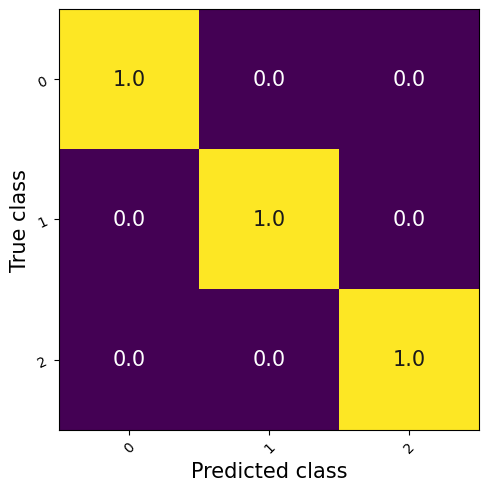

tensor([[12275,     1,     2],
        [    0,   133,     0],
        [    0,     0,   133]])
Macro F1-Score: 0.9962 ✨
perclass_f1scores: tensor([0.9999, 0.9963, 0.9925])
perclass_precision: tensor([1.0000, 0.9925, 0.9852])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 0.5602 ✨
MAE per_class: {1: np.float64(0.5789473684210527), 2: np.float64(0.5413533834586466)} ✨
 =============== Currently Evaluating curr_test_idx: 11 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_13_T1/13_1_2mW_IPh

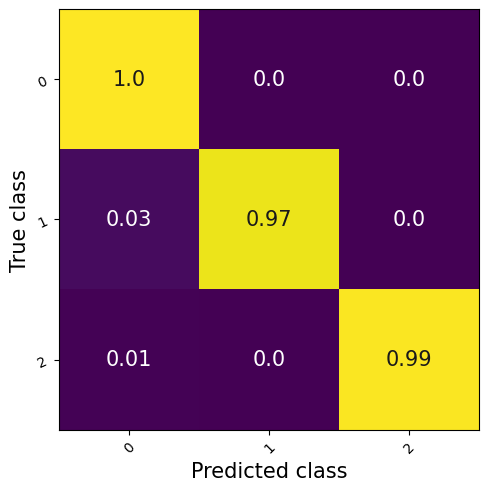

tensor([[12525,     5,     4],
        [    4,   129,     0],
        [    1,     0,   132]])
Macro F1-Score: 0.9824 ✨
perclass_f1scores: tensor([0.9994, 0.9663, 0.9814])
perclass_precision: tensor([0.9996, 0.9627, 0.9706])
perclass_recall: tensor([0.9993, 0.9699, 0.9925])
MAE overall: 0.8830 ✨
MAE per_class: {1: np.float64(1.0681818181818181), 2: np.float64(0.6992481203007519)} ✨
 =============== Currently Evaluating curr_test_idx: 12 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_14_T1/14_1_2mW_IPh

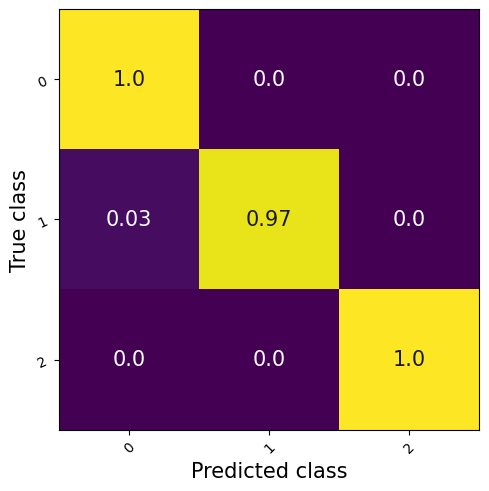

tensor([[12499,     6,     1],
        [    5,   142,     0],
        [    0,     0,   147]])
Macro F1-Score: 0.9863 ✨
perclass_f1scores: tensor([0.9995, 0.9627, 0.9966])
perclass_precision: tensor([0.9996, 0.9595, 0.9932])
perclass_recall: tensor([0.9994, 0.9660, 1.0000])
MAE overall: 1.0850 ✨
MAE per_class: {1: np.float64(1.7619047619047619), 2: np.float64(0.40816326530612246)} ✨
 =============== Currently Evaluating curr_test_idx: 13 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_15_T1/15_1_2mW_IP

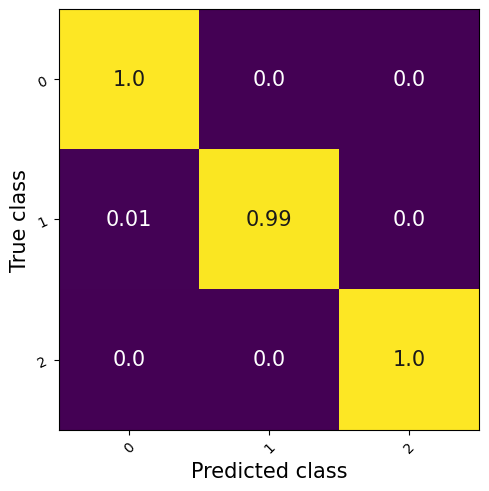

tensor([[12497,     1,     2],
        [    1,   149,     0],
        [    0,     0,   150]])
Macro F1-Score: 0.9955 ✨
perclass_f1scores: tensor([0.9998, 0.9933, 0.9934])
perclass_precision: tensor([0.9999, 0.9933, 0.9868])
perclass_recall: tensor([0.9998, 0.9933, 1.0000])
MAE overall: 0.6600 ✨
MAE per_class: {1: np.float64(0.5666666666666667), 2: np.float64(0.7533333333333333)} ✨
 =============== Currently Evaluating curr_test_idx: 14 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_16_T1/16_1_2mW_IPh

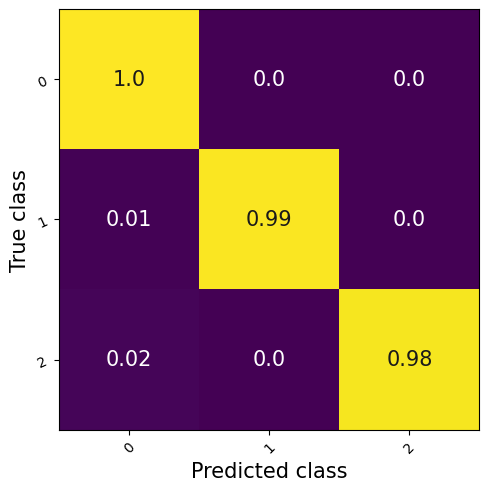

tensor([[12283,     0,     1],
        [    1,   129,     0],
        [    2,     0,   128]])
Macro F1-Score: 0.9948 ✨
perclass_f1scores: tensor([0.9998, 0.9961, 0.9884])
perclass_precision: tensor([0.9998, 1.0000, 0.9922])
perclass_recall: tensor([0.9999, 0.9923, 0.9846])
MAE overall: 1.2519 ✨
MAE per_class: {1: np.float64(0.6589147286821705), 2: np.float64(1.8449612403100775)} ✨
 =============== Currently Evaluating curr_test_idx: 20 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_23_T1/23_1_2mW_IPh

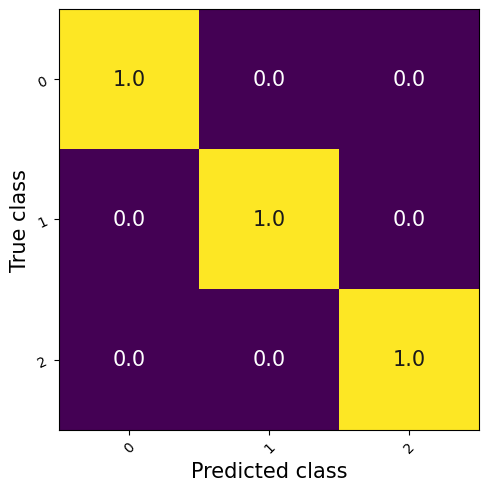

tensor([[12541,     2,     1],
        [    0,   128,     0],
        [    0,     0,   128]])
Macro F1-Score: 0.9961 ✨
perclass_f1scores: tensor([0.9999, 0.9922, 0.9961])
perclass_precision: tensor([1.0000, 0.9846, 0.9922])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 1.4062 ✨
MAE per_class: {1: np.float64(1.03125), 2: np.float64(1.78125)} ✨
 =============== Currently Evaluating curr_test_idx: 23 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_26_T1/26_1_2mW_IPhone.xls
cropped_array 

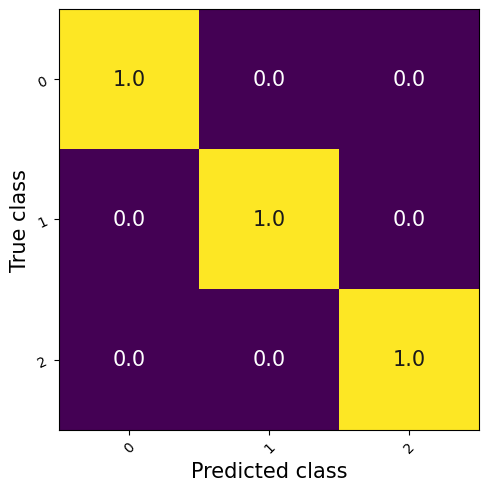

tensor([[12527,     2,     1],
        [    0,   135,     0],
        [    0,     0,   135]])
Macro F1-Score: 0.9963 ✨
perclass_f1scores: tensor([0.9999, 0.9926, 0.9963])
perclass_precision: tensor([1.0000, 0.9854, 0.9926])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 0.7963 ✨
MAE per_class: {1: np.float64(0.4222222222222222), 2: np.float64(1.1703703703703703)} ✨
 =============== Currently Evaluating curr_test_idx: 24 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_27_T1/27_1_2mW_IPh

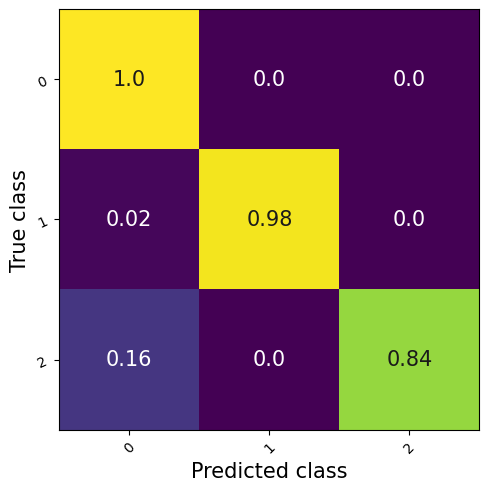

tensor([[12577,     3,     5],
        [    2,   106,     0],
        [   17,     0,    90]])
Macro F1-Score: 0.9557 ✨
perclass_f1scores: tensor([0.9989, 0.9770, 0.8911])
perclass_precision: tensor([0.9985, 0.9725, 0.9474])
perclass_recall: tensor([0.9994, 0.9815, 0.8411])
MAE overall: 0.9849 ✨
MAE per_class: {1: np.float64(1.1495327102803738), 2: np.float64(0.7934782608695652)} ✨
 =============== Currently Evaluating curr_test_idx: 28 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_31_T1/31_1_2mW_IPh

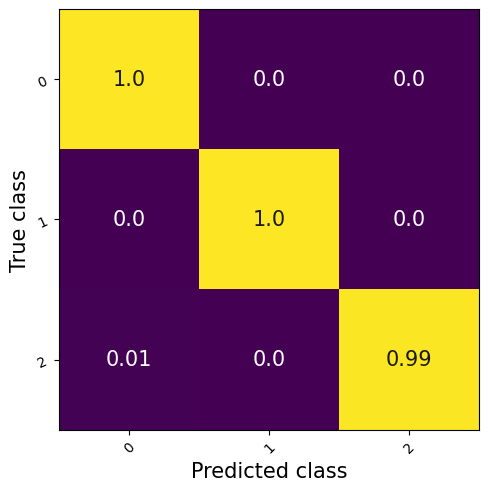

tensor([[12265,     3,     1],
        [    0,   138,     0],
        [    1,     0,   136]])
Macro F1-Score: 0.9939 ✨
perclass_f1scores: tensor([0.9998, 0.9892, 0.9927])
perclass_precision: tensor([0.9999, 0.9787, 0.9927])
perclass_recall: tensor([0.9997, 1.0000, 0.9927])
MAE overall: 1.1934 ✨
MAE per_class: {1: np.float64(1.2318840579710144), 2: np.float64(1.1544117647058822)} ✨
 =============== Currently Evaluating curr_test_idx: 34 =============== 
train_stats: {'mean': array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781,
        0.86179046]), 'std': array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,
       5.12151813])}
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
====++++Enters ZSCALE in GAITDATASET====++++
/home/qivy00li/projects/gait_ml/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_37_T1/37_1_2mW_IPh

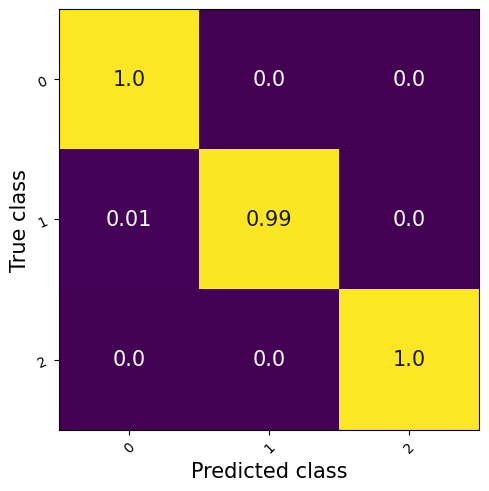

tensor([[12542,     3,     0],
        [    1,   127,     0],
        [    0,     0,   127]])
Macro F1-Score: 0.9948 ✨
perclass_f1scores: tensor([0.9998, 0.9845, 1.0000])
perclass_precision: tensor([0.9999, 0.9769, 1.0000])
perclass_recall: tensor([0.9998, 0.9922, 1.0000])
MAE overall: 1.0196 ✨
MAE per_class: {1: np.float64(1.34375), 2: np.float64(0.6929133858267716)} ✨


In [19]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [2]
data_set = "test"

for i in range(num_folds):
    if i == 2:
        for j in exp_labels:
            # curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
            curr_model_path = np.sort(glob(f"/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold{i+1}*expandlabel{j}*/*/*"))[-1]
            save_name = f"Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
            if data_set == "test":
                save_name = f"{data_set}set_{save_name}"
            # if not os.path.exists(save_name):
            print(f"=== Running model: {save_name} ===")
            testset_results = eval(data_set=data_set, model_fpath=curr_model_path, fold=i, return_preds_targets=True)
            # np.savez(save_name, **testset_results)
    break

In [28]:
all_preds = testset_results["all_preds"]
all_targets = testset_results["all_targets"]

In [38]:
# Find all patient ids
# subject_ids = [Path(i).parents[3].name for i in test_set_fpaths]

# Take average feature per subject since there are ~
stance_pred = [utils.calculate_gait_phases_vectorized(i) for i in all_preds]
stance_target = [utils.calculate_gait_phases_vectorized(i) for i in all_targets]

stance_pred = pd.DataFrame([i.mean() for i in stance_pred])
stance_target = pd.DataFrame([i.mean() for i in stance_target])
# stance_pred = utils.aggregate_res(stance_pred, subject_ids)
# stance_target = utils.aggregate_res(stance_target, subject_ids)

In [39]:
res_df = pd.concat([stance_pred, stance_target], axis=1)
res_df

,0,0
0,61.988527,61.998176
1,59.176889,59.513763
2,60.881147,61.092694
3,59.880227,59.978442
4,59.908133,60.097155
5,57.099935,57.110981
6,56.924522,56.951606
7,63.833932,64.963275
8,58.963472,59.531568
9,60.085249,60.102315


/beegfs1/home/qivy00li/projects/gait_ml/src/gait_ml/utils.py:174: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(


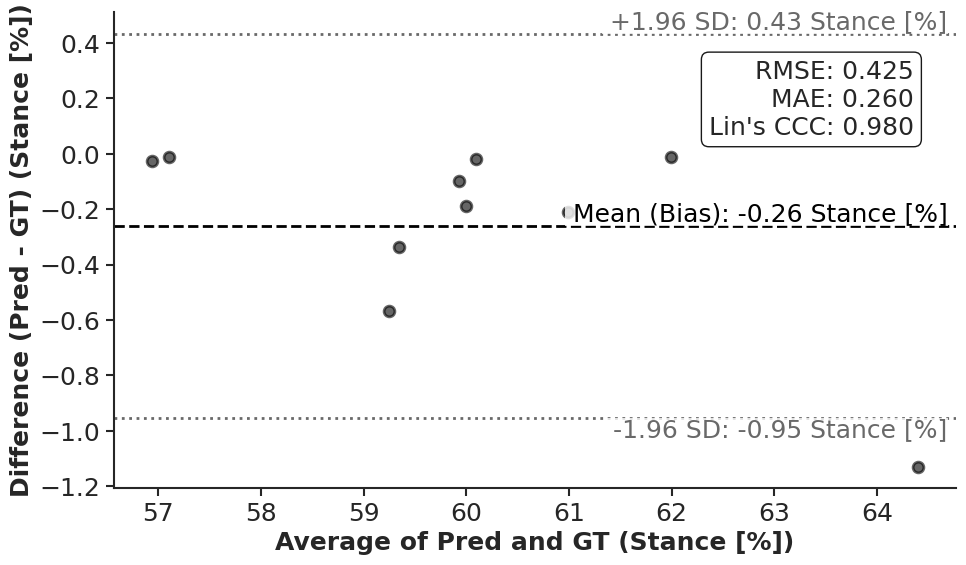

In [40]:
# 2. Call the plotting function
fig, ax = utils.plot_bland_altman_publication(
    res_df.iloc[:, 0], 
    res_df.iloc[:, 1], 
    method1_name='Pred',
    method2_name='GT',
    units='Stance [%]'  # <-- Specify the units here
)

In [ ]:
a